# Import packages

In [1]:
import numpy as np

import pandas as pd    
import optax 
import jax 
import jax.numpy as jnp   
from jax import grad, jit

# 2D input and 1 output

W shape: (64, 2)
b shape: (64,)
W shape: (64, 64)
b shape: (64,)
W shape: (1, 64)
b shape: (1,)
Epoch 0, Loss = 2.5343e-02
Epoch 200, Loss = 4.3863e-04
Epoch 400, Loss = 1.8261e-04
Epoch 600, Loss = 7.6959e-05
Epoch 800, Loss = 4.5862e-05
Epoch 1000, Loss = 3.1960e-05


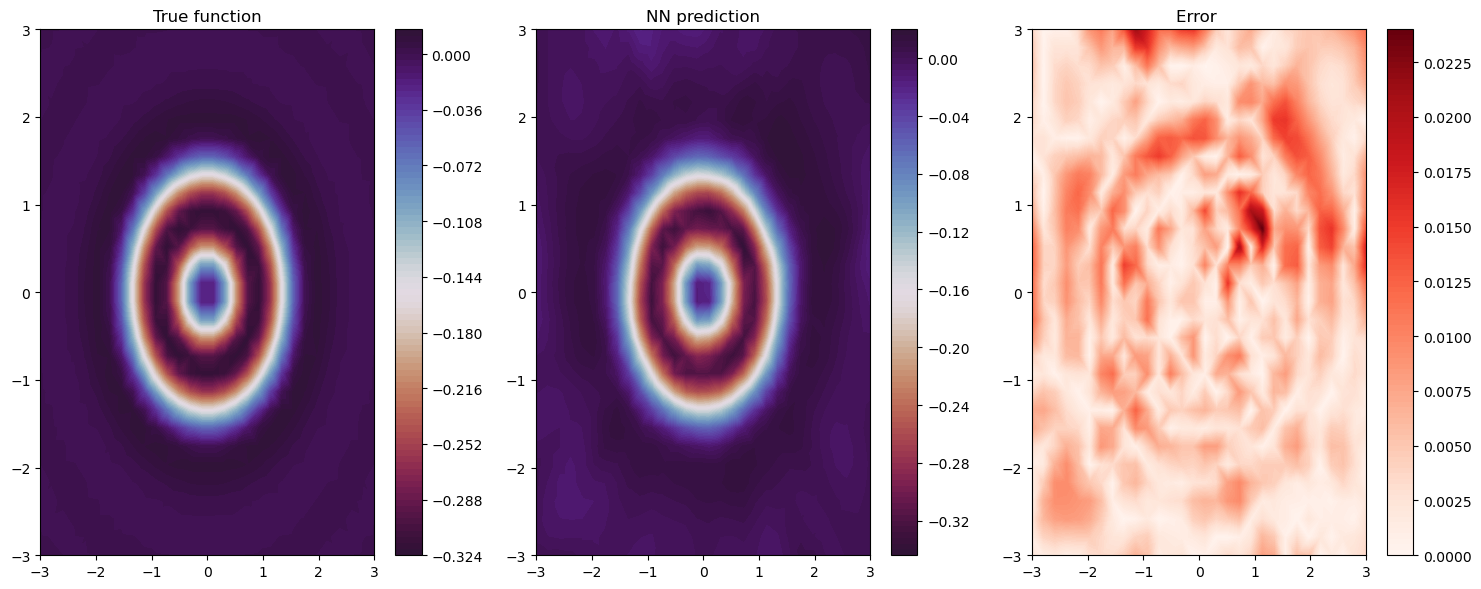

In [2]:
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt

# ---- 真の関数 ----
def f_true(x, y):
    return jnp.exp(-(x**2 + y**2)) * jnp.sin(-(x**2 + y**2))

# ---- データ ----
key = jax.random.PRNGKey(0)
n_train = 2000
x_train = jax.random.uniform(key, (n_train, 2), minval=-3, maxval=3)
y_train = f_true(x_train[:, 0], x_train[:, 1]).reshape(-1, 1)

# ---- MLP ----
def init_mlp(layer_sizes, key):
    keys = jax.random.split(key, len(layer_sizes))
    params = []
    for m, n, k in zip(layer_sizes[:-1], layer_sizes[1:], keys):
        w_key, _ = jax.random.split(k)
        W = jax.random.normal(w_key, (n, m)) * jnp.sqrt(2/m)
        b = jnp.zeros((n,))
        params.append((W, b))
        print("W shape:",W.shape)
        print("b shape:", b.shape)
    return params

def mlp(params, x):
    for W, b in params[:-1]:
        x = jax.nn.tanh(jnp.dot(x, W.T) + b)
    W, b = params[-1]
    return jnp.dot(x, W.T) + b  # 出力層は線形

# ---- 損失関数 ----
def loss_fn(params, x, y):
    pred = mlp(params, x)
    return jnp.mean((pred - y) ** 2)

# ---- 最適化 ----
lr = 1e-3
optimizer = optax.adam(lr)
params = init_mlp([2, 64, 64, 1], key)
opt_state = optimizer.init(params)

@jax.jit
def update(params, opt_state, x, y):
    grads = jax.grad(loss_fn)(params, x, y)
    updates, opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state

# ---- ミニバッチ学習 ----
def data_loader(x, y, batch_size, key):
    idx = jax.random.permutation(key, len(x))
    for i in range(0, len(x), batch_size):
        batch_idx = idx[i:i+batch_size]
        yield x[batch_idx], y[batch_idx]

# ---- 学習ループ ----
for epoch in range(1001):
    for xb, yb in data_loader(x_train, y_train, 128, key):
        params, opt_state = update(params, opt_state, xb, yb)
    if epoch % 200 == 0:
        l = loss_fn(params, x_train, y_train)
        print(f"Epoch {epoch}, Loss = {l:.4e}")

# ---- 可視化 ----
x = jnp.linspace(-3, 3, 30)
y = jnp.linspace(-3, 3, 30)

# 全組み合わせを作成
X = jnp.repeat(x, len(y))
Y = jnp.tile(y, len(x))
XY = jnp.stack([X, Y], axis=1)

# 予測と真値を計算
Z_true = f_true(XY[:, 0], XY[:, 1])
Z_pred = jax.vmap(lambda x: mlp(params, x))(XY).flatten()


# ---- プロット ----
fig, axs = plt.subplots(1, 3, figsize=(15, 6))
im0 = axs[0].tricontourf(XY[:,0], XY[:,1], Z_true, cmap = "twilight_shifted_r",levels = 100)
axs[0].set_title("True function")
im1 = axs[1].tricontourf(XY[:,0], XY[:,1], Z_pred, cmap = "twilight_shifted_r",levels = 100)
axs[1].set_title("NN prediction")

im2 = axs[2].tricontourf(XY[:,0], XY[:,1], np.abs(Z_pred-Z_true), cmap = "Reds",levels = 100)
axs[2].set_title("Error ")

plt.colorbar(im0, ax=axs[0])
plt.colorbar(im1, ax=axs[1])
plt.colorbar(im2, ax=axs[2])
plt.tight_layout()
plt.show()
